# EDA and Feature Engineering for Steam Games Dataset

In [67]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter, defaultdict

pd.set_option('display.max_columns', None)

In [2]:
# Load Data
dataset = load_dataset(
    "FronkonGames/steam-games-dataset",
    split='train'
)

df = dataset.to_pandas()

print(df.shape)
display(df.head())

(124146, 41)


,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,supported_languages,full_audio_languages,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,user_score,positive,negative,score_rank,achievements,recommendations,notes,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,[],[],,https://shared.akamai.steamstatic.com/store_it...,,,,True,False,False,0,,0,0,0,,0,0,,0,0,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",[English],[],,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,252,3,,0,231,,8,0,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,"[English, French, German, Russian]",[],,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,,0,21,3,,0,0,,0,0,0,0,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,[Korean],[Korean],,https://shared.akamai.steamstatic.com/store_it...,,,yujingamesc@gmail.com,True,False,False,0,,0,0,0,,19,0,The game includes the following elements. 1. G...,0,0,0,0,[유진게임즈],[유진게임즈],"[Single-player, Steam Achievements, Family Sha...","[Casual, Indie, Simulation]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy \ubc84\ud29c\ubc84 \ud30c\ub77..."
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,[English],[English],,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,,0,0,0,,0,0,,0,0,0,0,[Reality Expanded LLC],[Reality Expanded LLC],"[Single-player, VR Only, Steam Leaderboards, F...","[Action, Early Access]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Maze Quest VR"", ""description"":..."


In [3]:
# Summary
def safe_nunique(series):
    try:
        return series.nunique()
    except TypeError:
        return series.apply(
            lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
        ).nunique()


summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": [safe_nunique(df[col]) for col in df.columns]
})

summary.sort_values("missing_pct", ascending=False)

display(summary)

,dtype,non_null,missing,missing_pct,unique
appID,str,124146,0,0.0,124146
name,str,124146,0,0.0,122974
release_date,str,124146,0,0.0,5113
estimated_owners,str,124146,0,0.0,14
peak_ccu,int64,124146,0,0.0,1110
required_age,int64,124146,0,0.0,15
price,float64,124146,0,0.0,944
dlc_count,int64,124146,0,0.0,117
detailed_description,str,124146,0,0.0,115137
short_description,str,124146,0,0.0,114560


In [4]:
df['release_date'] = pd.to_datetime(df["release_date"], errors="coerce")
year_df = df[(df['release_date'].dt.year >= 2015) & (df['release_date'].dt.year < 2026)].copy()

year_df["has_metacritic"] = np.where(
    year_df["metacritic_score"] > 0,
    "Yes",
    "No"
)

print(year_df.shape)

print(year_df["has_metacritic"].value_counts())

print(year_df['estimated_owners'].value_counts())

(119036, 42)
has_metacritic
No     116225
Yes      2811
Name: count, dtype: int64
estimated_owners
0 - 20000                74853
0 - 0                    21516
20000 - 50000            10791
50000 - 100000            4811
100000 - 200000           2952
200000 - 500000           2283
500000 - 1000000           872
1000000 - 2000000          532
2000000 - 5000000          268
5000000 - 10000000          87
10000000 - 20000000         39
20000000 - 50000000         23
50000000 - 100000000         7
100000000 - 200000000        2
Name: count, dtype: int64


In [25]:
# Check for missing values in the metacritic_url column
year_df["has_metacritic_score_url"] = np.where(
    year_df["metacritic_url"].fillna("").str.strip().ne(""),
    "Yes",
    "No"
)

print(year_df["has_metacritic_score_url"].value_counts())

# Same as checking for "0" in score... can be dropped
year_df.drop(columns=["has_metacritic_score_url"], inplace=True)

has_metacritic_score_url
No     116225
Yes      2811
Name: count, dtype: int64


release_date
2015     2515
2016     4141
2017     5921
2018     7461
2019     7242
2020     8804
2021    11067
2022    12285
2023    14596
2024    20031
2025    24973
Name: count, dtype: int64


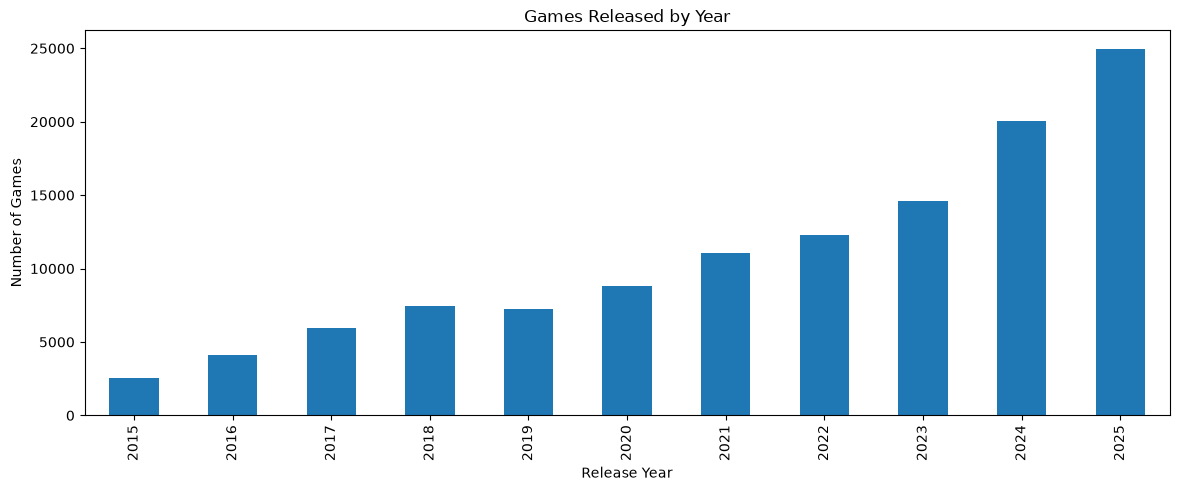

In [6]:
# Count of games released per year and plot
print(year_df['release_date'].dt.year.value_counts().sort_index())

(
    year_df["release_date"].dt.year
    .value_counts()
    .sort_index()
    .plot(kind="bar", figsize=(14, 5))
)

plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.title("Games Released by Year")
plt.show()

## Metacritic Score by Ownership

In [7]:
# Compare owner distributions across metacritic groups

owner_order = [
    "0 - 0",
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "1000000 - 2000000",
    "2000000 - 5000000",
    "5000000 - 10000000",
    "10000000 - 20000000",
    "20000000 - 50000000",
    "50000000 - 100000000",
    "100000000 - 200000000"
]

year_df["estimated_owners"] = pd.Categorical(
    year_df["estimated_owners"],
    categories=owner_order,
    ordered=True
)

pd.crosstab(
    year_df["estimated_owners"],
    year_df["has_metacritic"],
    normalize="columns"
).round(3)

has_metacritic,No,Yes
estimated_owners,,
0 - 0,0.185,0.003
0 - 20000,0.640,0.187
20000 - 50000,0.089,0.143
50000 - 100000,0.038,0.122
100000 - 200000,0.022,0.133
200000 - 500000,0.016,0.166
500000 - 1000000,0.005,0.095
1000000 - 2000000,0.003,0.076
2000000 - 5000000,0.001,0.047


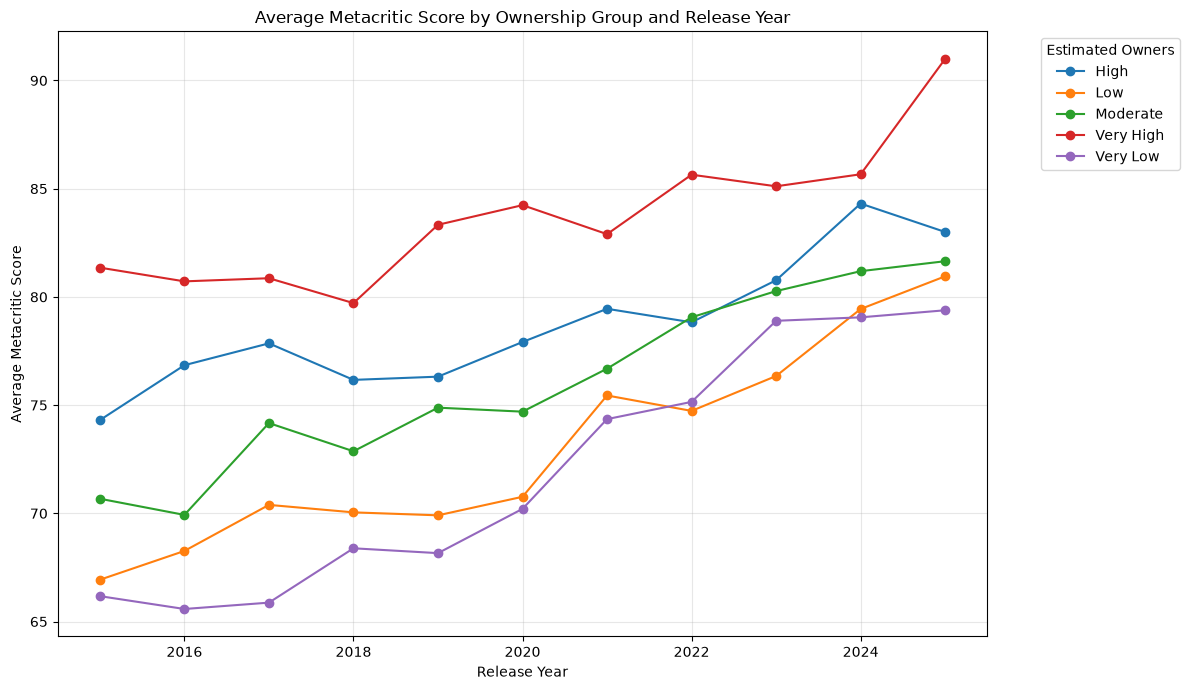

In [75]:
owner_groups = {
    "0 - 0": "Very Low",
    "0 - 20000": "Very Low",
    "20000 - 50000": "Low",
    "50000 - 100000": "Low",
    "100000 - 200000": "Moderate",
    "200000 - 500000": "Moderate",
    "500000 - 1000000": "High",
    "1000000 - 2000000": "High",
    "2000000 - 5000000": "Very High",
    "5000000 - 10000000": "Very High",
    "10000000 - 20000000": "Very High",
    "20000000 - 50000000": "Very High",
    "50000000 - 100000000": "Very High",
    "100000000 - 200000000": "Very High"
}

year_df["owner_group"] = (
    year_df["estimated_owners"]
    .astype(str)
    .map(owner_groups)
)

year_df['release_year'] = year_df['release_date'].dt.year

mc_by_year = (
        year_df[year_df["has_metacritic"] == 'Yes']
    .groupby(["release_year", "owner_group"], observed=True)
    .agg(
        avg_metacritic=("metacritic_score", "mean"),
        n_games=("metacritic_score", "count")
    )
    .reset_index()
)

# display(mc_by_year)

# Line chart
plt.figure(figsize=(12, 7))

for group in mc_by_year["owner_group"].dropna().unique():
    temp = mc_by_year[mc_by_year["owner_group"] == group]

    plt.plot(
        temp["release_year"],
        temp["avg_metacritic"],
        marker="o",
        label=group
    )

plt.xlabel("Release Year")
plt.ylabel("Average Metacritic Score")
plt.title("Average Metacritic Score by Ownership Group and Release Year")

plt.legend(
    title="Estimated Owners",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Owners by year

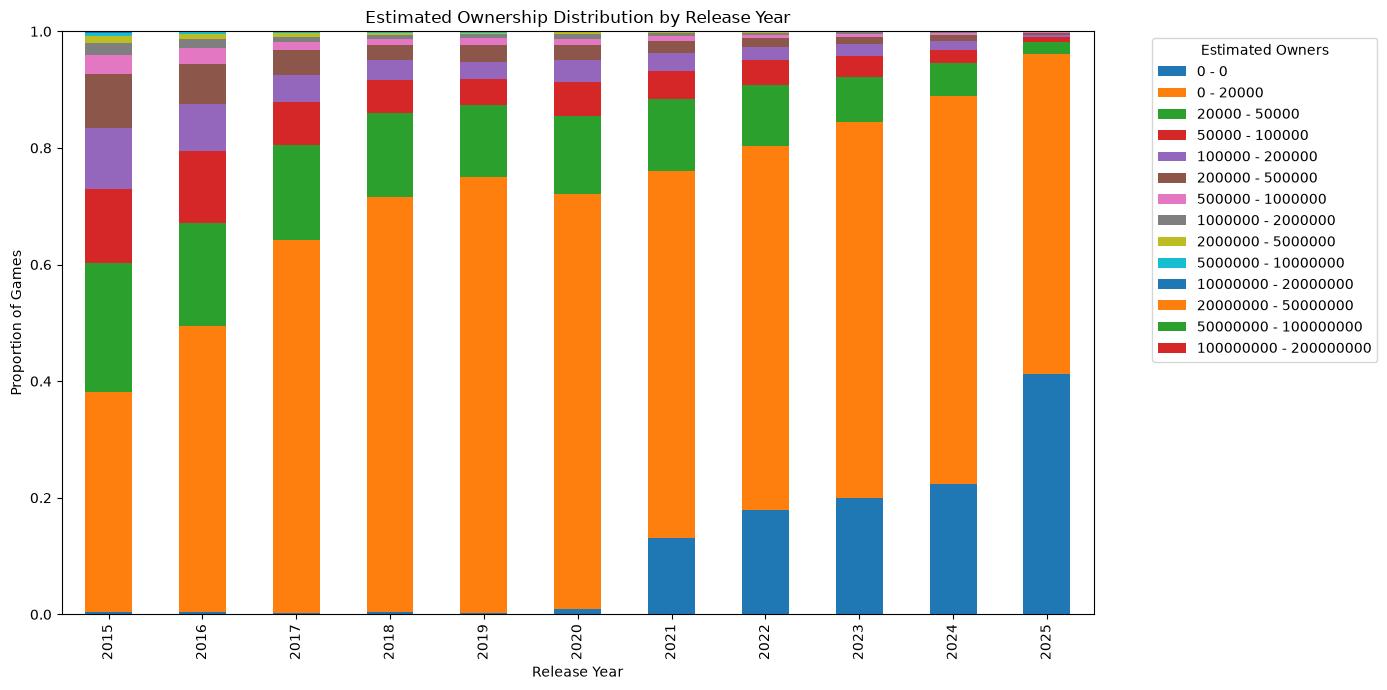

In [14]:
owner_order = [
    "0 - 0",
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "1000000 - 2000000",
    "2000000 - 5000000",
    "5000000 - 10000000",
    "10000000 - 20000000",
    "20000000 - 50000000",
    "50000000 - 100000000",
    "100000000 - 200000000"
]

year_df["owner_group"] = pd.Categorical(
    year_df["estimated_owners"],
    categories=owner_order,
    ordered=True
)

owner_by_year = pd.crosstab(
    year_df["release_year"],
    year_df["owner_group"],
    normalize="index"
)

owner_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel("Release Year")
plt.ylabel("Proportion of Games")
plt.title("Estimated Ownership Distribution by Release Year")
plt.legend(
    title="Estimated Owners",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Publishers EDA

In [ ]:
# Number of publishers per game
year_df["n_publishers"] = year_df["publishers"].apply(
    lambda x: len(x) if isinstance(x, np.ndarray) else 0
)

year_df["n_publishers"].describe()

count    119036.000000
mean          0.965809
std           0.347241
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: n_publishers, dtype: float64

In [16]:
# Distribution of publishers
year_df["n_publishers"].value_counts().sort_index()

n_publishers
0       8705
1     106172
2       3739
3        385
4         24
5          7
6          2
8          1
10         1
Name: count, dtype: int64

In [27]:
# Unique publishers
pubs_df = year_df[["appID", "publishers"]].explode("publishers")
pubs_df["publishers"].nunique()
print("Unique publishers:", pubs_df["publishers"].nunique())
print("Missing:", pubs_df["publishers"].isna().sum())

# Top 20 publishers by number of games published
publisher_counts = pubs_df["publishers"].value_counts()
display(publisher_counts.head(20))

Unique publishers: 62047
Missing: 8705


publishers
BFG Entertainment                  540
8floor                             268
EroticGamesClub                    231
PlayWay S.A.                       214
Kagura Games                       194
Conglomerate 5                     190
Hede                               184
HH-Games                           179
Laush Studio                       172
Choice of Games                    171
Sekai Project                      164
Boogygames Studios                 157
Plug In Digital                    147
DigiPen Institute of Technology    145
My Way Games                       143
Gamersky Games                     138
Bully Revenge Studios              135
Gamesforgames                      135
Alawar Casual                      132
SA Industry                        124
Name: count, dtype: int64

In [19]:
# Distribution of publishers by ownership
year_df["has_publisher"] = year_df["n_publishers"] > 0

pd.crosstab(
    year_df["estimated_owners"],
    year_df["has_publisher"],
    normalize="columns"
).round(3)

has_publisher,False,True
estimated_owners,,
0 - 0,0.960,0.119
0 - 20000,0.028,0.676
20000 - 50000,0.005,0.097
50000 - 100000,0.003,0.043
100000 - 200000,0.001,0.027
200000 - 500000,0.001,0.021
500000 - 1000000,0.001,0.008
1000000 - 2000000,0.000,0.005
2000000 - 5000000,0.000,0.002


## Developers EDA

In [29]:
# Number of developers per game
year_df["n_devs"] = year_df["developers"].apply(
    lambda x: len(x) if isinstance(x, np.ndarray) else 0
)

display(year_df["n_devs"].describe())

# Distribution of devs
year_df["n_devs"].value_counts().sort_index()

count    119036.000000
mean          1.020767
std           0.584338
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          41.000000
Name: n_devs, dtype: float64

n_devs
0       8391
1     103105
2       6104
3        778
4        273
5        169
6         70
7         48
8         29
9         16
10        10
11         6
12         6
13         6
14         4
15         3
16         3
17         3
18         3
20         2
21         2
22         1
23         2
31         1
41         1
Name: count, dtype: int64

In [34]:
# Unique developers
devs_df = year_df[["appID", "developers"]].explode("developers")
devs_df["developers"].nunique()
print("Unique developers:", devs_df["developers"].nunique())
print("Missing:", devs_df["developers"].isna().sum())

# Top 20 developers by number of games developed
developer_counts = devs_df["developers"].value_counts()
display(developer_counts.head(12))

Unique developers: 74299
Missing: 8391


developers
EroticGamesClub               231
Choice of Games               171
Boogygames Studios            157
Laush Dmitriy Sergeevich      152
Creobit                       144
Bully Revenge Studios         135
Gamesforgames                 132
Tero Lunkka                   123
Hosted Games                  118
Cyber Keks                    117
KOEI TECMO GAMES CO., LTD.    117
Sokpop Collective             112
Name: count, dtype: int64

In [47]:
# Developer games and ownership distribution
dev_owner_df = (
    year_df[["appID", "developers", "estimated_owners"]]
    .explode("developers")
    .dropna(subset=["developers"])
    .reset_index(drop=True)
)

dev_owner_df["developers"] = (
    dev_owner_df["developers"]
    .astype(str)
    .str.strip()
)

dev_owner_df = dev_owner_df[dev_owner_df["developers"] != ""]

dev_owner_df["estimated_owners"] = (
    dev_owner_df["estimated_owners"]
    .astype(str).str.strip()
)

developer_owners = pd.crosstab(
    dev_owner_df["developers"],
    dev_owner_df["estimated_owners"]
)

existing_owner_cols = [col for col in owner_order if col in developer_owners.columns]

developer_owners = developer_owners.reindex(columns=existing_owner_cols, fill_value='')

developer_owners["total_games"] = (developer_owners.sum(axis=1))

developer_owners = developer_owners.sort_values(
    "total_games",
    ascending=False
)

print("\nDeveloper ownership counts:")
display(developer_owners.sample(10))


Developer ownership counts:


estimated_owners,0 - 0,0 - 20000,20000 - 50000,50000 - 100000,100000 - 200000,200000 - 500000,500000 - 1000000,1000000 - 2000000,2000000 - 5000000,5000000 - 10000000,10000000 - 20000000,20000000 - 50000000,50000000 - 100000000,100000000 - 200000000,total_games
developers,,,,,,,,,,,,,,,
Deboma,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
SuperStructureGames,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Hedgehog Game Studios,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Johannes Förth,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Erochin,1,0,1,0,0,0,0,0,0,0,0,0,0,0,2
Bonus Level Entertainment,0,1,2,0,0,0,0,0,0,0,0,0,0,0,3
李梓涛,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
Warehouse Studios,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Solitude Software,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


## Supported Languages

In [58]:
unique_languages = np.unique(
    np.concatenate(year_df["supported_languages"].dropna().values)
).tolist()

print(unique_languages)

['Afrikaans', 'Albanian', 'Amharic', 'Arabic', 'Armenian', 'Assamese', 'Azerbaijani', 'Bangla', 'Basque', 'Belarusian', 'Bosnian', 'Bulgarian', 'Catalan', 'Cherokee', 'Croatian', 'Czech', 'Danish', 'Dari', 'Dutch', 'English', 'Estonian', 'Filipino', 'Finnish', 'French', 'Galician', 'Georgian', 'German', 'Greek', 'Gujarati', 'Hausa', 'Hebrew', 'Hindi', 'Hungarian', 'Icelandic', 'Igbo', 'Indonesian', 'Irish', 'Italian', 'Japanese', "K'iche'", 'Kannada', 'Kazakh', 'Khmer', 'Kinyarwanda', 'Konkani', 'Korean', 'Kyrgyz', 'Latvian', 'Lithuanian', 'Luxembourgish', 'Macedonian', 'Malay', 'Malayalam', 'Maltese', 'Maori', 'Marathi', 'Mongolian', 'Nepali', 'Norwegian', 'Odia', 'Persian', 'Polish', 'Portuguese - Brazil', 'Portuguese - Portugal', 'Punjabi (Gurmukhi)', 'Punjabi (Shahmukhi)', 'Quechua', 'Romanian', 'Russian', 'Scots', 'Serbian', 'Simplified Chinese', 'Sindhi', 'Sinhala', 'Slovak', 'Slovenian', 'Sorani', 'Sotho', 'Spanish - Latin America', 'Spanish - Spain', 'Swahili', 'Swedish', 'Taji

## Genres

In [61]:
from collections import Counter
import pandas as pd

# Count each genre across all games
genre_counts = Counter(
    genre
    for genres in year_df["genres"]
    for genre in genres
)

genre_counts_df = (
    pd.DataFrame(
        genre_counts.items(),
        columns=["genre", "n_games"]
    )
    .sort_values("n_games", ascending=False)
    .reset_index(drop=True)
)

genre_counts_df["pct_games"] = (
    genre_counts_df["n_games"] / len(year_df) * 100
)

genre_counts_df

,genre,n_games,pct_games
0,Indie,78975,66.345475
1,Casual,49350,41.458046
2,Action,44689,37.542424
3,Adventure,44026,36.985450
4,Simulation,23622,19.844417
5,Strategy,21539,18.094526
6,RPG,20387,17.126752
7,Free To Play,12026,10.102826
8,Early Access,11027,9.263584
9,Sports,4794,4.027353


In [62]:
# Num genres per game
year_df["num_genres"] = year_df["genres"].apply(len)

year_df["num_genres"].describe()

count    119036.000000
mean          2.701712
std           1.500025
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          19.000000
Name: num_genres, dtype: float64

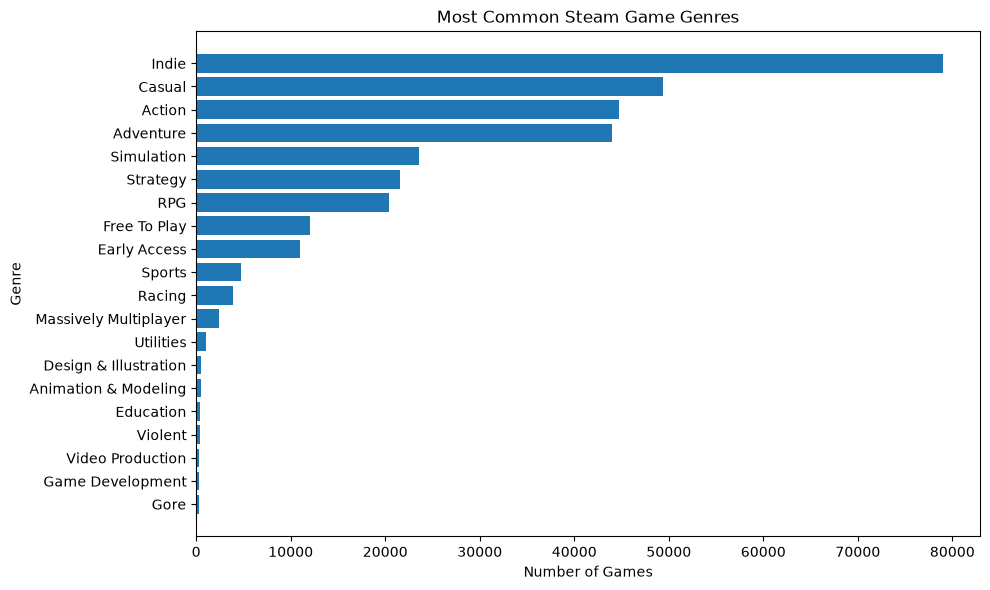

In [64]:
# Plot of the top 20 genres by number of games
top_genres = genre_counts_df.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres["genre"][::-1],
    top_genres["n_games"][::-1]
)

plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.title("Most Common Steam Game Genres")

plt.tight_layout()
plt.show()

In [65]:
# Co-occurrence of genres
genre_combinations = (
    year_df["genres"]
    .apply(lambda x: tuple(sorted(x)))
    .value_counts()
    .reset_index()
)

genre_combinations.columns = ["genres", "n_games"]

genre_combinations.head(20)

,genres,n_games
0,(),8397
1,"(Casual, Indie)",6618
2,"(Action, Indie)",5448
3,"(Action, Adventure, Indie)",5027
4,"(Adventure, Indie)",4166
5,"(Adventure, Casual, Indie)",3528
6,"(Action, Casual, Indie)",3363
7,"(Casual,)",3214
8,"(Indie,)",3015
9,"(Action,)",2627


In [68]:
genre_pairs = Counter()

for genres in year_df["genres"]:
    for pair in combinations(sorted(set(genres)), 2):
        genre_pairs[pair] += 1

genre_pairs_df = (
    pd.DataFrame(
        [
            {
                "genre_1": pair[0],
                "genre_2": pair[1],
                "n_games": count
            }
            for pair, count in genre_pairs.items()
        ]
    )
    .sort_values("n_games", ascending=False)
    .reset_index(drop=True)
)

genre_pairs_df.head(20)

,genre_1,genre_2,n_games
0,Casual,Indie,37890
1,Action,Indie,34068
2,Adventure,Indie,33580
3,Action,Adventure,20501
4,Adventure,Casual,17426
5,Indie,Simulation,16747
6,Indie,Strategy,15521
7,Action,Casual,15242
8,Indie,RPG,14801
9,Casual,Simulation,12352


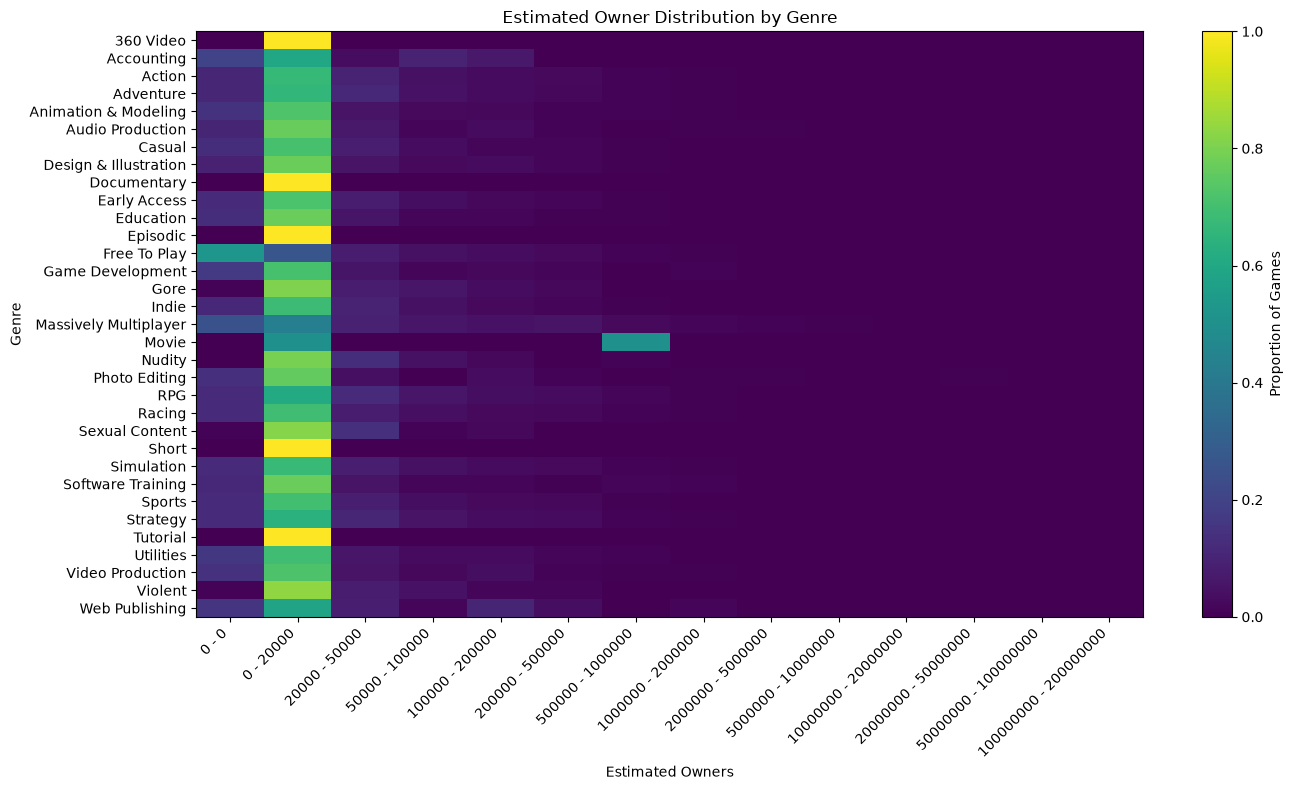

In [72]:
# Genres by Ownership Group
genre_owner_counts = (
    year_df[["genres", "estimated_owners"]]
    .explode("genres")
    .groupby(["genres", "estimated_owners"])
    .size()
    .unstack(fill_value=0)
)

genre_owner_pct = genre_owner_counts.div(
    genre_owner_counts.sum(axis=1),
    axis=0
)

plt.figure(figsize=(14, 8))

plt.imshow(
    genre_owner_pct,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Proportion of Games")

plt.xticks(
    range(len(genre_owner_pct.columns)),
    genre_owner_pct.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(genre_owner_pct.index)),
    genre_owner_pct.index
)

plt.xlabel("Estimated Owners")
plt.ylabel("Genre")
plt.title("Estimated Owner Distribution by Genre")

plt.tight_layout()
plt.show()

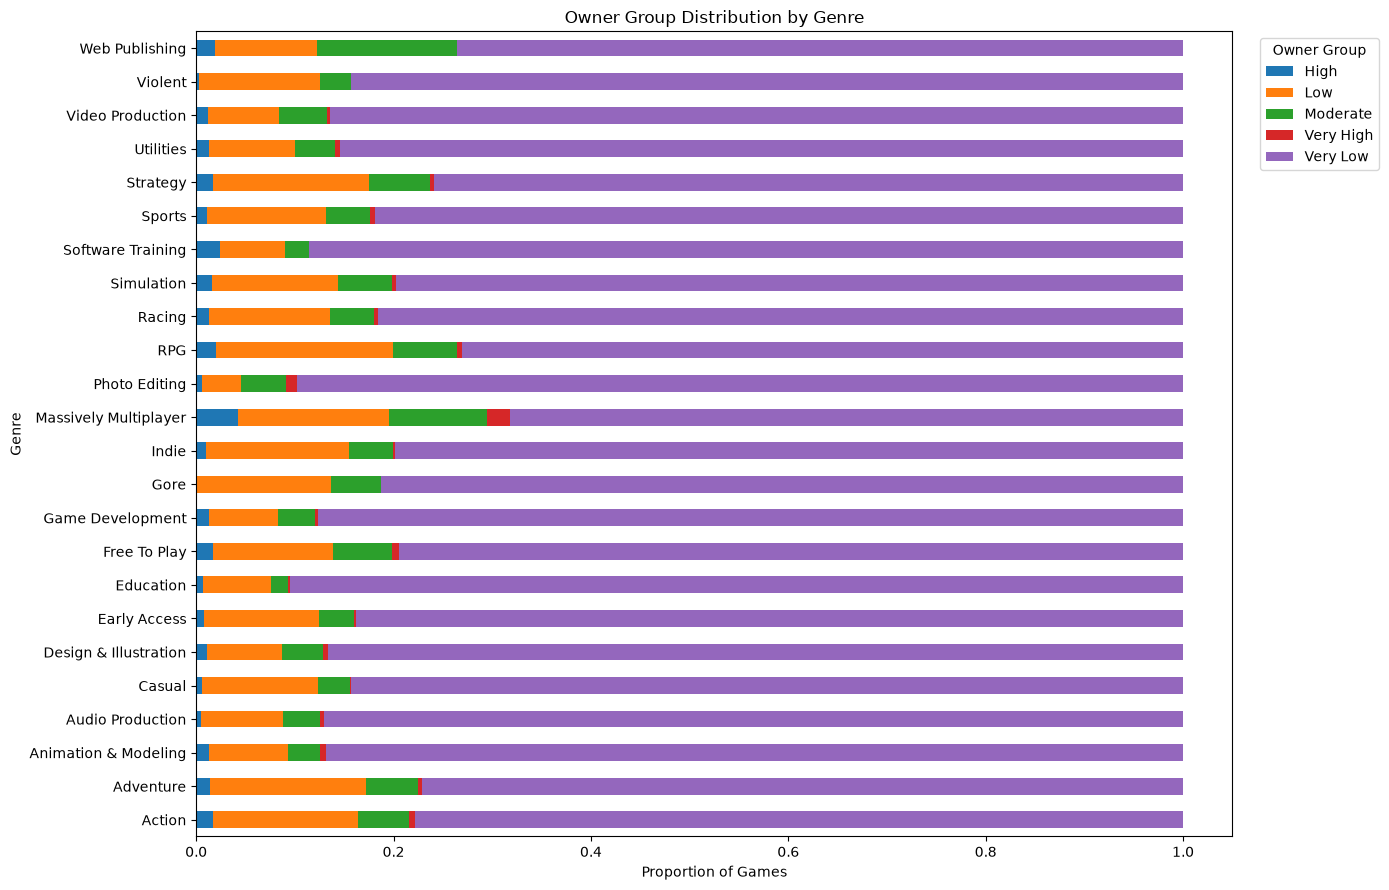

In [80]:
genre_owner_counts = (
    year_df[["genres", "owner_group"]]
    .explode("genres")
    .groupby(["genres", "owner_group"])
    .size()
    .unstack(fill_value=0)
)

genre_owner_pct = genre_owner_counts.div(
    genre_owner_counts.sum(axis=1),
    axis=0
)

genre_n = (
    year_df["genres"]
    .explode()
    .value_counts()
)

min_games = 100

keep_genres = genre_n[genre_n >= min_games].index

plot_data = genre_owner_pct.loc[
    genre_owner_pct.index.isin(keep_genres)
]

plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 9)
)

plt.xlabel("Proportion of Games")
plt.ylabel("Genre")
plt.title("Owner Group Distribution by Genre")

plt.legend(
    title="Owner Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Inspecting rows that might not be a video game

In [83]:
non_game_genres = [
    "Accounting",
    "Animation & Modeling",
    "Audio Production",
    "Design & Illustration",
    "Education",
    "Game Development",
    "Movie",
    "Photo Editing",
    "Software Training",
    "Utilities",
    "Video Production",
    "Web Publishing",
    "360 Video"
]

non_game_rows = year_df[
    year_df["genres"].apply(
        lambda genres: any(
            genre in non_game_genres
            for genre in genres
        )
    )
]

non_game_rows[['name', 'detailed_description', 'genres']].sample(10)

,name,detailed_description,genres
36746,Snapshot - DSLR Camera Control,"Introducing Snapshot , an application that all...","[Photo Editing, Software Training, Utilities]"
34981,Fast video cutter joiner,Video Cutter and Video Joiner 2-in-1 This is a...,[Video Production]
555,Mind Massaging Machine,Is your mind tired? Do you want to feel your m...,[Utilities]
109077,School Fab Lab VR,School Fab Lab Virtual Reality (SFL VR) makes ...,[Education]
87959,INU,INU is animated licking doge screenmate applic...,"[Casual, Utilities]"
855,Restrictr,Sick of hitting walls or obstacles where playi...,[Utilities]
80978,Firefly Studio,Firefly Studio is a Virtual YouTuber software....,"[Animation & Modeling, Video Production]"
36649,Dart Companion,The ultimate companion app for darts players –...,"[Sports, Strategy, Utilities]"
62544,Fire Safety Lab VR,Fire Safety Lab VR gives theoretical informati...,[Education]
98394,SVFI,An AI software dedicated to high-performance o...,"[Animation & Modeling, Design & Illustration, ..."


## Categories

In [87]:
cat_counts = Counter(
    category
    for categories in year_df["categories"]
    for category in categories
)

cat_counts_df = (
    pd.DataFrame(
        cat_counts.items(),
        columns=["category", "n_games"]
    )
    .sort_values("n_games", ascending=False)
    .reset_index(drop=True)
)

cat_counts_df["pct_games"] = (
    cat_counts_df["n_games"] / len(year_df) * 100
)

cat_counts_df

,category,n_games,pct_games
0,Single-player,104605,87.876777
1,Family Sharing,92608,77.798313
2,Steam Achievements,54042,45.399711
3,Steam Cloud,29082,24.431264
4,Full controller support,24774,20.812191
5,Multi-player,19126,16.067408
6,Partial Controller Support,13054,10.966430
7,PvP,12381,10.401055
8,Co-op,10571,8.880507
9,Steam Trading Cards,10061,8.452065
